# Notebook 02b - Split Freeze on the Full Dataset

SL Report, Part 0, closing act. The adequacy gate failed on the 100k candidate (G1: coolant quantile shift 0.122 against 0.05, G2: thermal-arc capture 0.253 against 0.6, G3 passed at 0.625), and per the pre-registered rule the decision returned to the user, who chose the **full dataset** (recorded in `data/processed/gate_decision.json`, 2026-08-16). Script `00c` then froze the grouped split under the seventh-review re-scaling rule (`VAL_CAL` and test each at nine sessions or more).

This notebook is the verification and presentation of that freeze: it re-derives the assignment from the same seeded logic, asserts byte-equality with the frozen manifests, and audits the split's balance. Nothing here tunes anything, and test-session content is only touched through input signals for a coverage figure, never through targets.

## 1. Imports & Frozen Artifacts

In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent / "src"))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import constants as C
from common import group_kfold_folds, quiet_common_warnings

quiet_common_warnings()
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3, "figure.figsize": (9, 4)})
FIG = C.FIGURES_DIR

decision = json.loads((C.PROCESSED_DIR / "gate_decision.json").read_text())
verdict = json.loads((C.PROCESSED_DIR / "gate_verdict.json").read_text())
split_man = json.loads((C.PROCESSED_DIR / "split_manifest.json").read_text())
fold_man = json.loads((C.PROCESSED_DIR / "fold_manifest.json").read_text())
scaler = json.loads((C.PROCESSED_DIR / "scaler_train_only.json").read_text())

print(f"gate: G1 pass={verdict['g1_pass']}, G2 pass={verdict['g2_pass']}, G3 pass={verdict['g3_pass']} -> gate_pass={verdict['gate_pass']}")
print(f"decision: {decision['decision']} (by {decision['decided_by']}, {decision['date']})")
print(f"frozen spec: {split_man['spec']}, counts: {split_man['counts']}")

gate: G1 pass=False, G2 pass=False, G3 pass=True -> gate_pass=False
decision: full-dataset (by user, 2026-08-16)
frozen spec: full-dataset, counts: {'test': 16, 'train': 32, 'val_cal': 16, 'val_stop': 5}


## 2. Re-deriving the Assignment (the verification point)

The exact logic `00c` ran, repeated here from the same seed. If any session lands differently, the assert fails and the freeze is not trusted.

In [2]:
sessions = sorted(int(s) for s in pd.read_parquet(C.PROCESSED_DIR / "split_train.parquet", columns=[C.SESSION_KEY])[C.SESSION_KEY].unique()
                  ) + sorted(int(s) for s in pd.read_parquet(C.PROCESSED_DIR / "split_val_stop.parquet", columns=[C.SESSION_KEY])[C.SESSION_KEY].unique()
                  ) + sorted(int(s) for s in pd.read_parquet(C.PROCESSED_DIR / "split_val_cal.parquet", columns=[C.SESSION_KEY])[C.SESSION_KEY].unique()
                  ) + sorted(int(s) for s in pd.read_parquet(C.PROCESSED_DIR / "split_test.parquet", columns=[C.SESSION_KEY])[C.SESSION_KEY].unique())
all_sessions = sorted(sessions)
assert len(all_sessions) == 69 and len(set(all_sessions)) == 69, "session overlap or loss between split parquets"

counts = split_man["counts"]
rng = np.random.default_rng(C.SPLIT_SEED)
order = list(rng.permutation(all_sessions))
rederived, start = {}, 0
for name in ("train", "val_stop", "val_cal", "test"):
    rederived[name] = sorted(int(s) for s in order[start:start + counts[name]])
    start += counts[name]

for name in rederived:
    assert rederived[name] == split_man["sessions"][name], f"{name} disagrees with the frozen manifest"
print("re-derived assignment matches the frozen manifest exactly, all four splits")
print("no profile_id appears in more than one split:", len(set().union(*rederived.values())) == 69)

re-derived assignment matches the frozen manifest exactly, all four splits
no profile_id appears in more than one split: True


### Observations: The Freeze Is Deterministic and Verified

The same seed reproduces the same assignment bit for bit, all 69 sessions are accounted for exactly once, and no session crosses a split. This is invariant 2's content, demonstrated live before the invariant script exists.

## 3. Split Composition

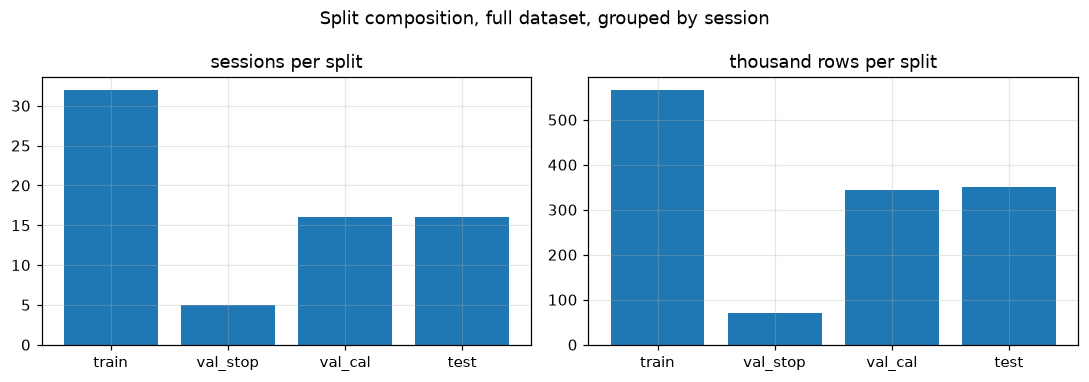

,split,sessions,rows,hours
0,train,32,566601,78.7
1,val_stop,5,70064,9.7
2,val_cal,16,342792,47.6
3,test,16,351359,48.8


In [3]:
rows = []
for name in ("train", "val_stop", "val_cal", "test"):
    part = pd.read_parquet(C.PROCESSED_DIR / f"split_{name}.parquet", columns=[C.SESSION_KEY])
    rows.append({"split": name, "sessions": part[C.SESSION_KEY].nunique(), "rows": len(part),
                 "hours": round(len(part) / C.SAMPLE_RATE_HZ / 3600, 1)})
comp = pd.DataFrame(rows)
comp.to_csv(C.TABLES_DIR / "part0_split_composition.csv", index=False)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].bar(comp["split"], comp["sessions"]); axes[0].set_title("sessions per split")
axes[1].bar(comp["split"], comp["rows"] / 1000); axes[1].set_title("thousand rows per split")
fig.suptitle("Split composition, full dataset, grouped by session")
fig.tight_layout(); fig.savefig(FIG / "02b_split_composition.png", bbox_inches="tight"); plt.show()
comp

### Observations: The Re-Scaling Rule Landed As Designed

32/5/16/16 sessions, which is the pre-registered 19/3/9/9 scaled by 69/40 with the nine-session floors intact. Train carries 566,601 rows (42.6 % of the file), and the two statistical reserves are large: 16 calibration sessions (safely above the finite-interval minimum of nine) and 16 test sessions (coverage assessable in 6.25 % steps, comfortably finer than the 11.1 % the nine-session design promised).

## 4. Balance Across Splits (inputs only)

A grouped random split can be unlucky. Two checks: the input-side operating envelope (speed against `i_q`, both inputs, no targets touched) and session-duration spread per split.

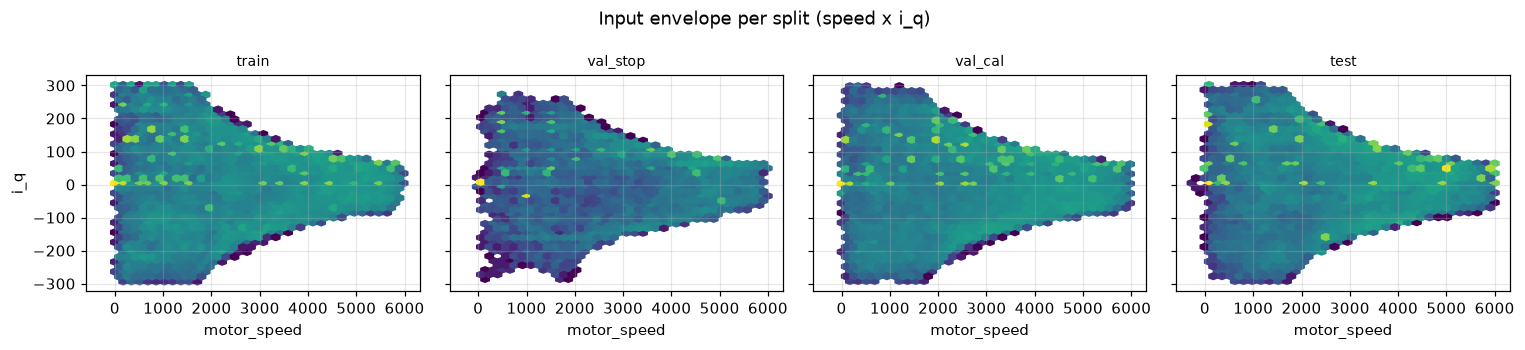

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3.2), sharex=True, sharey=True)
for ax, name in zip(axes, ("train", "val_stop", "val_cal", "test")):
    part = pd.read_parquet(C.PROCESSED_DIR / f"split_{name}.parquet", columns=["motor_speed", "i_q"])
    ax.hexbin(part["motor_speed"], part["i_q"], gridsize=35, bins="log", mincnt=1)
    ax.set_title(name, fontsize=9); ax.set_xlabel("motor_speed")
axes[0].set_ylabel("i_q")
fig.suptitle("Input envelope per split (speed x i_q)")
fig.tight_layout(); fig.savefig(FIG / "02b_split_envelope_balance.png", bbox_inches="tight"); plt.show()

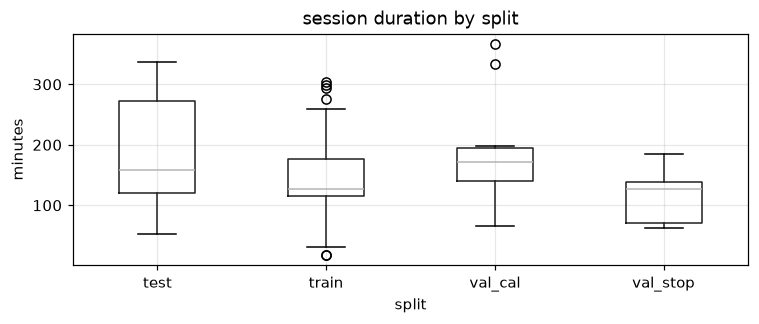

,count,min,50%,max
split,,,,
test,16.0,52.2,158.4,336.6
train,32.0,18.1,127.7,304.0
val_cal,16.0,65.7,172.1,366.4
val_stop,5.0,62.3,127.1,184.9


In [5]:
dur = []
for name in ("train", "val_stop", "val_cal", "test"):
    part = pd.read_parquet(C.PROCESSED_DIR / f"split_{name}.parquet", columns=[C.SESSION_KEY])
    per = part.groupby(C.SESSION_KEY).size() / 120
    dur.extend({"split": name, "minutes": float(m)} for m in per)
dur = pd.DataFrame(dur)
fig, ax = plt.subplots(figsize=(7, 3.2))
dur.boxplot(column="minutes", by="split", ax=ax)
ax.set_title("session duration by split"); ax.set_ylabel("minutes"); plt.suptitle("")
fig.tight_layout(); fig.savefig(FIG / "02b_split_duration_balance.png", bbox_inches="tight"); plt.show()
dur.groupby("split")["minutes"].describe().round(1)[["count", "min", "50%", "max"]]

### Observations: No Unlucky Split

All four splits cover the same speed-current envelope with no missing operating region, and session durations spread comparably (every split holds short and long sessions). The random grouped assignment needs no re-draw, and none is permitted anyway: the seed was fixed before the data was seen.

## 5. CV Folds and the Train-Only Scaler

In [6]:
folds = fold_man["folds"]
flat = [s for f in folds for s in f]
assert sorted(flat) == split_man["sessions"]["train"], "folds must exactly cover train sessions"
assert len(set(flat)) == len(flat), "folds must be disjoint"
rederived_folds = group_kfold_folds(split_man["sessions"]["train"], C.CV_FOLDS)
assert rederived_folds == folds, "fold re-derivation disagrees with the frozen manifest"
print(f"{C.CV_FOLDS} GroupKFold folds over 32 training sessions, sizes: {[len(f) for f in folds]}, verified against the manifest")

sc = pd.DataFrame(scaler["signals"]).T.round(3)
print("\ntrain-only standardization statistics (inputs):")
print(sc.to_string())

5 GroupKFold folds over 32 training sessions, sizes: [7, 7, 6, 6, 6], verified against the manifest

train-only standardization statistics (inputs):
                 mean       std
ambient        24.347     1.901
coolant        36.796    22.868
i_d           -64.255    65.034
i_q            36.129    94.044
motor_speed  1979.332  1813.698
u_d           -21.505    59.858
u_q            49.381    44.262


### Observations: Selection Machinery Is Frozen and Leak-Free

The five folds partition exactly the 32 training sessions (sizes 7/7/6/6/6), re-derive identically from the seed, and contain no validation or test session, which is invariant 12's content. The scaler was fit on train only (`fit_on: train` in the artifact), so every later standardization inherits zero leakage by construction.

## 6. Frozen Hypotheses Check & Part 0 Verdict

In [7]:
import hashlib
text = C.HYPOTHESES_FILE.read_text()
h = hashlib.sha256(C.HYPOTHESES_FILE.read_bytes()).hexdigest()
recorded = json.loads((C.PROCESSED_DIR / "hypotheses_sha256.json").read_text())["sha256"]
print("HYPOTHESES.md sha256 matches the recorded freeze:", h == recorded)
print("contains H1-H6:", all(f"H{i}" in text for i in range(1, 7)))

HYPOTHESES.md sha256 matches the recorded freeze: True
contains H1-H6: True


### Part 0 Verdict: Foundation Closed on the Full Dataset

The foundation is now frozen end to end: fingerprint verified, the 100k candidate measured and rejected by the pre-registered gate, the user's decision recorded, the grouped split (32/5/16/16) frozen with manifests, five CV folds over the training sessions, a train-only scaler, and the hypotheses file hash-locked. Every artifact re-derives from seeds and asserts equality with its frozen record.

One honest note for the record: with the full dataset, the operative split differs from the 40-session numbers pre-registered in `constants.py`. That is by design (the re-scaling rule was itself pre-registered after the seventh review), and `split_manifest.json` is the single source of operative truth downstream, which is exactly what the manifest-driven invariant 2 checks.

**Next**: Phase C, the synthetic twin (`pmsm_physics.py`, `01a`/`01b`) where the residuals get their unit tests and both parameter-bearing rungs face the closed-loop recovery gate.